# Customer Purchase Propensity — Data Cleaning & Feature Engineering Pipeline
**Role:** Junior Data Analyst, e-commerce company
**Goal:** Clean, preprocess, and engineer features from raw multi-source data to prepare it for a future ML model predicting `purchased` (1/0). No model is trained here — the focus is entirely on the preprocessing/feature-engineering pipeline.

## Step 1: Project Planning & Problem Framing

**What is Data Analysis?**
Data analysis is the process of inspecting, cleaning, transforming, and modeling data to discover useful information, draw conclusions, and support decision-making. It combines statistics, domain knowledge, and programming to turn raw, messy data into something a business or a model can act on.

**Steps in a Data Science project**
- Problem definition / framing
- Data collection (multiple sources: files, databases, APIs)
- Data cleaning & preprocessing (missing values, outliers, types)
- Exploratory Data Analysis (EDA)
- Feature engineering & transformation
- Model building & evaluation (out of scope for this exercise)
- Deployment & monitoring

**Framing this dataset as an ML problem**
This is a **binary classification** problem. The target variable is `purchased` (1 = customer made a purchase, 0 = did not). Features come from customer demographics (`customers.csv`), transaction behavior (`transactions.json`), product attributes (`products.sql`), and enriched user profile data (API). The pipeline below prepares a single clean, model-ready table.

## Step 2: Data Import and Understanding

In [1]:
import pandas as pd
import numpy as np
import json
import sqlite3
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
np.random.seed(42)

In [2]:
# --- Load customers.csv ---
customers = pd.read_csv("/Users/devjoshi/Desktop/Data Preprocessig/Practicle_Test/customers.csv")
print(customers.shape)
customers.head()

(500, 8)


,customer_id,age,gender,income,region,education,satisfaction_level,signup_date
0,CUST0001,56.0,Male,NaN,East,Bachelors,High,2024-08-02
1,CUST0002,69.0,Male,NaN,West,Bachelors,High,2021-08-17
2,CUST0003,46.0,Male,87312.96,West,High School,High,2021-02-21
3,CUST0004,32.0,Female,53658.86,West,Bachelors,High,2022-07-18
4,CUST0005,60.0,Male,65194.12,Central,NaN,High,2022-05-17


In [3]:
# --- Load transactions.json ---
with open("/Users/devjoshi/Desktop/Data Preprocessig/Practicle_Test/transactions.json") as f:
    txn_raw = json.load(f)
transactions = pd.DataFrame(txn_raw)
print(transactions.shape)
transactions.head()

(2006, 7)


,transaction_id,customer_id,product_id,purchase_date,amount,quantity,purchased
0,TXN000001,CUST0001,P017,2023-02-27,6.67,1.0,0
1,TXN000002,CUST0001,P001,2024-05-10,85.67,1.0,1
2,TXN000003,CUST0002,P035,2023-09-09,50.61,1.0,1
3,TXN000004,CUST0002,P013,2023-06-16,71.05,1.0,1
4,TXN000005,CUST0002,P022,2023-11-28,73.67,3.0,1


In [4]:
# --- Load products.sql into SQLite and read into a DataFrame ---
conn = sqlite3.connect(":memory:")
with open("/Users/devjoshi/Desktop/Data Preprocessig/Practicle_Test/products.sql") as f:
    conn.executescript(f.read())
products = pd.read_sql_query("SELECT * FROM products", conn)
print(products.shape)
products.head()

(40, 5)


,product_id,product_name,category,price,rating
0,P001,Product 1,Toys,16.27,4.9
1,P002,Product 2,Apparel,400.36,3.0
2,P003,Product 3,Apparel,150.90,5.0
3,P004,Product 4,Home & Kitchen,193.03,4.5
4,P005,Product 5,Toys,228.93,4.7


In [5]:
# --- Load API user-detail data (simulated response saved from https://dummyjson.com/users style endpoint) ---
with open("/Users/devjoshi/Desktop/Data Preprocessig/Practicle_Test/api_users_response.json") as f:
    api_raw = json.load(f)
api_users = pd.DataFrame(api_raw)
print(api_users.shape)
api_users.head()

(500, 5)


,customer_id,first_name,last_name,phone_verified,loyalty_tier
0,CUST0001,Casey,Johnson,True,Silver
1,CUST0002,Morgan,Smith,False,Platinum
2,CUST0003,Drew,Lee,True,Platinum
3,CUST0004,Jordan,Clark,False,Gold
4,CUST0005,Casey,Smith,False,Platinum


In [6]:
# --- Merge all sources on customer_id / product_id ---
txn_agg = transactions.groupby("customer_id").agg(
    total_purchases=("transaction_id", "count"),
    total_spent=("amount", "sum"),
    avg_order_value=("amount", "mean"),
    last_purchase_date=("purchase_date", "max"),
    purchased=("purchased", "max"),
).reset_index()

# bring in product-level info via a representative (most frequent) product per customer
top_product = (transactions.groupby(["customer_id", "product_id"]).size()
               .reset_index(name="cnt")
               .sort_values("cnt", ascending=False)
               .drop_duplicates("customer_id"))
top_product = top_product.merge(products, on="product_id", how="left")[
    ["customer_id", "product_id", "category", "price", "rating"]]

df = customers.merge(txn_agg, on="customer_id", how="left")
df = df.merge(top_product, on="customer_id", how="left")
df = df.merge(api_users, on="customer_id", how="left")

print(df.shape)
df.head()

(500, 21)


,customer_id,age,gender,income,region,education,satisfaction_level,signup_date,total_purchases,total_spent,avg_order_value,last_purchase_date,purchased,product_id,category,price,rating,first_name,last_name,phone_verified,loyalty_tier
0,CUST0001,56.0,Male,NaN,East,Bachelors,High,2024-08-02,2,92.34,46.170000,2024-05-10,1,P017,Beauty,336.17,3.8,Casey,Johnson,True,Silver
1,CUST0002,69.0,Male,NaN,West,Bachelors,High,2021-08-17,6,403.44,67.240000,2023-12-26,1,P035,Sports,130.15,3.4,Morgan,Smith,False,Platinum
2,CUST0003,46.0,Male,87312.96,West,High School,High,2021-02-21,2,73.20,36.600000,2024-03-28,1,P036,Electronics,322.89,4.0,Drew,Lee,True,Platinum
3,CUST0004,32.0,Female,53658.86,West,Bachelors,High,2022-07-18,4,116.02,38.673333,2024-01-07,1,P038,Sports,242.83,2.9,Jordan,Clark,False,Gold
4,CUST0005,60.0,Male,65194.12,Central,NaN,High,2022-05-17,2,82.29,41.145000,2023-10-19,1,P030,Sports,384.12,4.8,Casey,Smith,False,Platinum


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    str    
 1   age                 470 non-null    float64
 2   gender              485 non-null    str    
 3   income              460 non-null    float64
 4   region              490 non-null    str    
 5   education           475 non-null    str    
 6   satisfaction_level  480 non-null    str    
 7   signup_date         500 non-null    str    
 8   total_purchases     500 non-null    int64  
 9   total_spent         500 non-null    float64
 10  avg_order_value     500 non-null    float64
 11  last_purchase_date  500 non-null    str    
 12  purchased           500 non-null    int64  
 13  product_id          500 non-null    str    
 14  category            500 non-null    str    
 15  price               500 non-null    float64
 16  rating             

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,500,500,CUST0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,470.0,NaN,NaN,NaN,45.955319,20.705986,-5.0,33.0,45.0,57.75,200.0
gender,485,3,Male,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,460.0,NaN,NaN,NaN,59467.952391,36537.854369,12000.0,44795.2275,56966.695,70154.1775,581575.8
region,490,5,North,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,475,4,Bachelors,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satisfaction_level,480,4,High,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,500,415,2022-06-28,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_purchases,500.0,NaN,NaN,NaN,4.012,1.805096,1.0,3.0,4.0,5.0,11.0
total_spent,500.0,NaN,NaN,NaN,416.99168,397.857356,2.81,220.9125,332.23,500.435,3770.33


## Step 3: Exploratory Data Analysis (EDA)

### Univariate Analysis

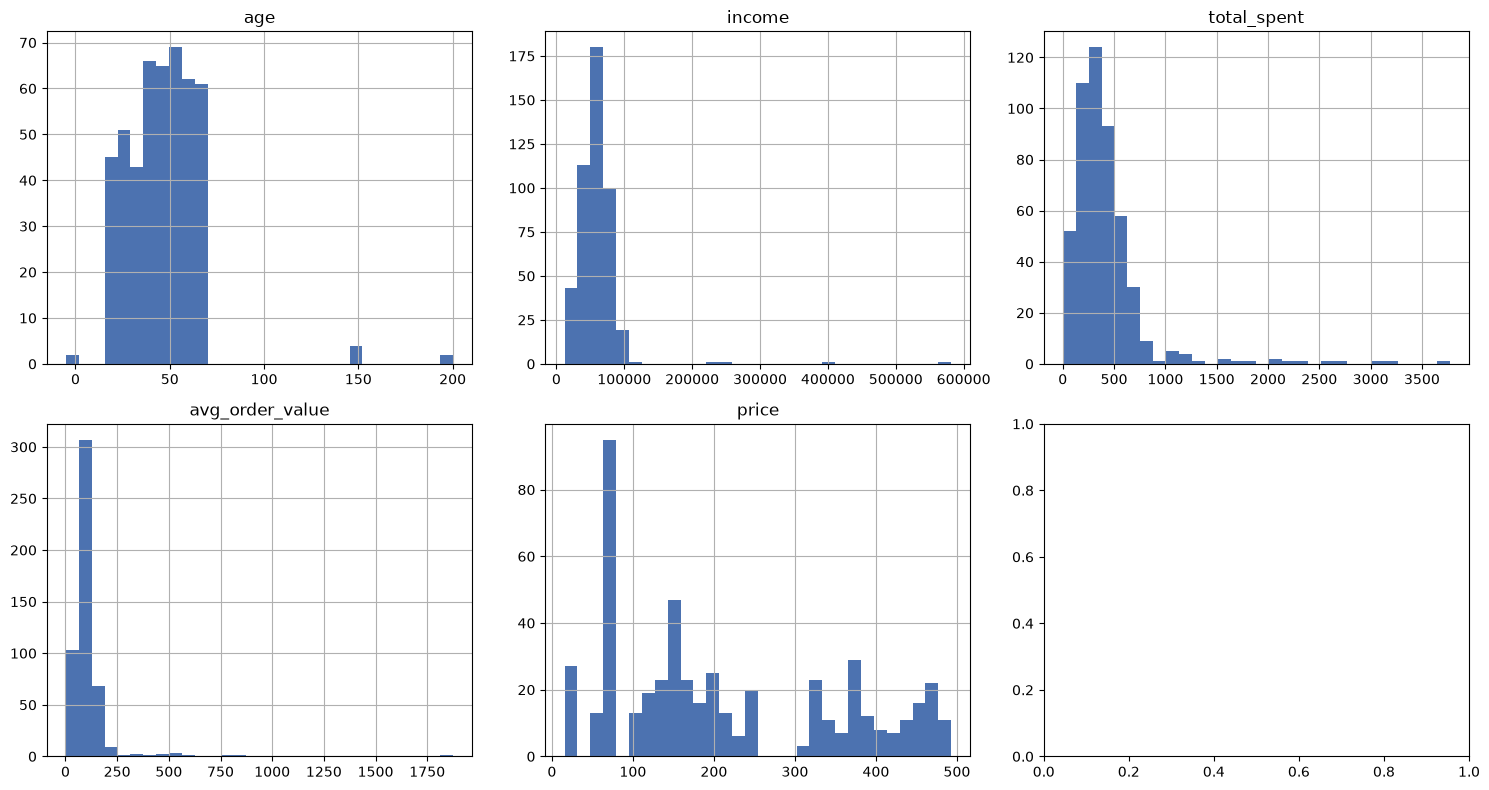

In [12]:
import matplotlib.pyplot as plt

num_cols = ["age", "income", "total_spent", "avg_order_value", "price"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=30, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("eda_univariate_histograms.png", dpi=100)
plt.show()

In [13]:
skew_report = df[num_cols].skew().sort_values(ascending=False)
print("Skewness of numerical columns:")
skew_report

Skewness of numerical columns:


avg_order_value    9.980971
income             8.633401
total_spent        4.331388
age                2.634891
price              0.533137
dtype: float64

**Observation:** `income` and `total_spent` are right-skewed (driven by the injected high-value outliers), which motivates the log/Box-Cox transformations applied in Step 9.

In [14]:
# Pandas Profiling / ydata-profiling style automated summary (lightweight fallback if package unavailable)
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title="Customer Data Profiling Report", minimal=True)
    profile.to_file("customer_data_profile.html")
    print("Profiling report saved to customer_data_profile.html")
except Exception as e:
    print("ydata-profiling not available in this environment, generating a manual summary instead.")
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    })
    try:
        display(summary)
    except NameError:
        print(summary)

ydata-profiling not available in this environment, generating a manual summary instead.


,dtype,missing_count,missing_pct,n_unique
customer_id,str,0,0.0,500
age,float64,30,6.0,55
gender,str,15,3.0,3
income,float64,40,8.0,456
region,str,10,2.0,5
education,str,25,5.0,4
satisfaction_level,str,20,4.0,4
signup_date,str,0,0.0,415
total_purchases,int64,0,0.0,11
total_spent,float64,0,0.0,498


### Bivariate Analysis

In [15]:
corr_cols = ["age", "income", "total_spent", "avg_order_value", "price", "rating", "purchased"]
corr_with_target = df[corr_cols].corr(numeric_only=True)["purchased"].sort_values(ascending=False)
print("Correlation of numerical features with target (purchased):")
corr_with_target

Correlation of numerical features with target (purchased):


purchased          1.000000
rating             0.076198
total_spent        0.069238
income             0.019334
price              0.013756
age                0.013355
avg_order_value   -0.019777
Name: purchased, dtype: float64

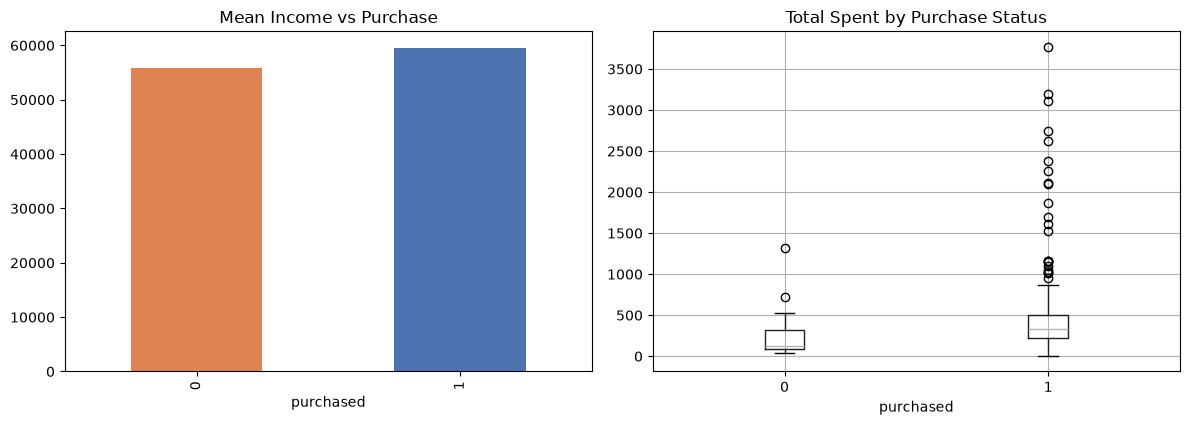

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
df.groupby("purchased")["income"].mean().plot(kind="bar", ax=ax[0], color=["#DD8452", "#4C72B0"])
ax[0].set_title("Mean Income vs Purchase")
ax[0].set_xlabel("purchased")

df.boxplot(column="total_spent", by="purchased", ax=ax[1])
ax[1].set_title("Total Spent by Purchase Status")
plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_bivariate.png", dpi=100)
plt.show()

### Multivariate Analysis

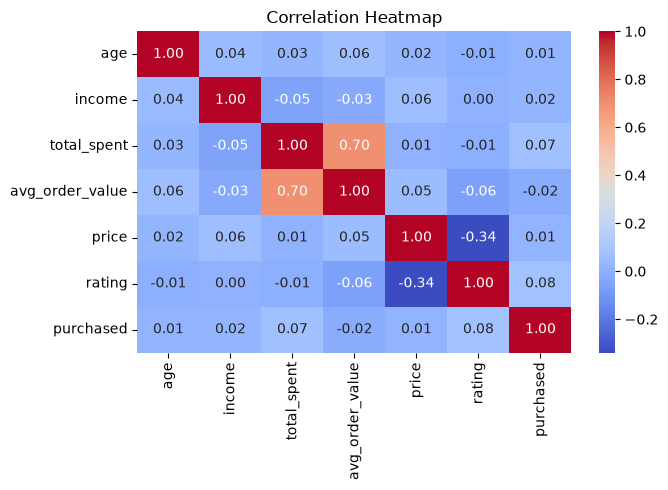

In [17]:
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_heatmap.png", dpi=100)
plt.show()

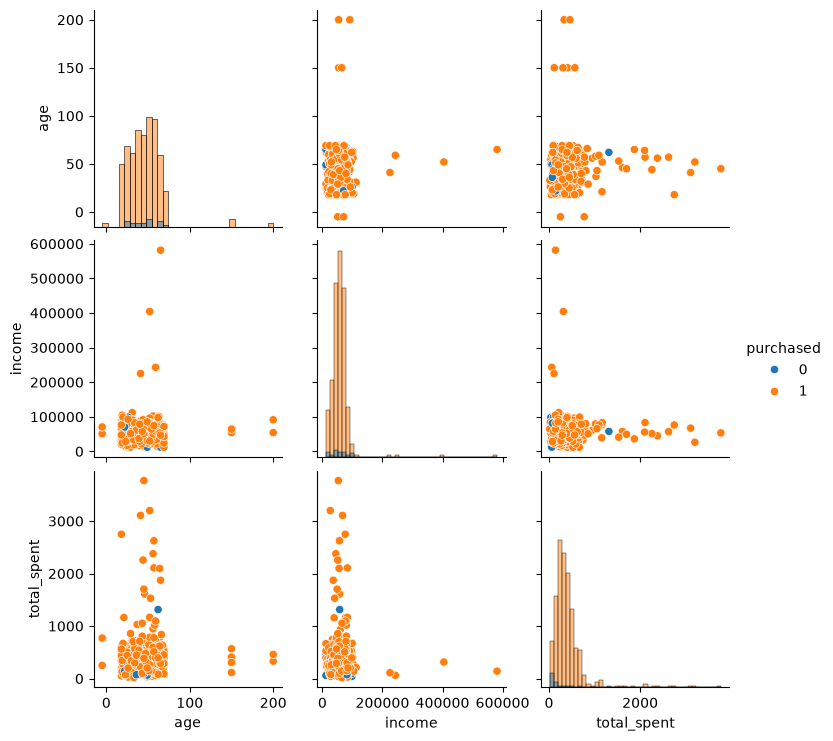

In [18]:
sns.pairplot(df[["age", "income", "total_spent", "purchased"]].dropna(), hue="purchased", diag_kind="hist")
plt.savefig("eda_pairplot.png", dpi=100)
plt.show()

In [19]:
grouped_stats = df.groupby(["region", "purchased"])[["income", "total_spent"]].mean().round(2)
grouped_stats

income  total_spent
region  purchased                       
Central 0          57661.59        97.05
        1          57427.48       456.07
East    0          74274.54        53.51
        1          62501.81       437.87
North   0          46898.66       339.94
        1          55911.37       453.27
South   0          47379.91       203.97
        1          59999.97       361.36
West    0          56695.87       340.84
        1          62671.00       407.91

## Step 4: Handling Missing Data

We compare several imputation strategies side by side.

In [20]:
print("Missing values per column:")
df.isna().sum()[df.isna().sum() > 0]

Missing values per column:


age                   30
gender                15
income                40
region                10
education             25
satisfaction_level    20
dtype: int64

In [21]:
from sklearn.impute import SimpleImputer

df_simple = df.copy()
num_impute_cols = ["age", "income", "price", "rating"]
cat_impute_cols = ["gender", "education", "region", "satisfaction_level", "category", "loyalty_tier"]

num_imputer = SimpleImputer(strategy="mean")
df_simple[num_impute_cols] = num_imputer.fit_transform(df_simple[num_impute_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_simple[cat_impute_cols] = cat_imputer.fit_transform(df_simple[cat_impute_cols])

print("SimpleImputer (mean) + Most Frequent Imputation done.")
df_simple[num_impute_cols + cat_impute_cols].isna().sum()

SimpleImputer (mean) + Most Frequent Imputation done.


age                   0
income                0
price                 0
rating                0
gender                0
education             0
region                0
satisfaction_level    0
category              0
loyalty_tier          0
dtype: int64

In [22]:
# Missing Indicator + Random Sample Imputation
df_indicator = df.copy()
for col in num_impute_cols:
    df_indicator[f"{col}_was_missing"] = df_indicator[col].isna().astype(int)
    observed = df_indicator[col].dropna()
    n_missing = df_indicator[col].isna().sum()
    if n_missing > 0:
        fill_values = observed.sample(n_missing, replace=True, random_state=42).values
        df_indicator.loc[df_indicator[col].isna(), col] = fill_values

print("Missing indicator flags created:", [c for c in df_indicator.columns if c.endswith("_was_missing")])
df_indicator[[c for c in df_indicator.columns if c.endswith("_was_missing")]].sum()

Missing indicator flags created: ['age_was_missing', 'income_was_missing', 'price_was_missing', 'rating_was_missing']


age_was_missing       30
income_was_missing    40
price_was_missing      0
rating_was_missing     0
dtype: int64

In [23]:
from sklearn.impute import KNNImputer

df_knn = df.copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[num_impute_cols] = knn_imputer.fit_transform(df_knn[num_impute_cols])
print("KNN Imputer applied to:", num_impute_cols)
df_knn[num_impute_cols].isna().sum()

KNN Imputer applied to: ['age', 'income', 'price', 'rating']


age       0
income    0
price     0
rating    0
dtype: int64

In [24]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

df_mice = df.copy()
mice_imputer = IterativeImputer(random_state=42, max_iter=10)
df_mice[num_impute_cols] = mice_imputer.fit_transform(df_mice[num_impute_cols])
print("MICE (IterativeImputer) applied - demonstrates chained imputation across correlated numeric features.")
df_mice[num_impute_cols].isna().sum()

MICE (IterativeImputer) applied - demonstrates chained imputation across correlated numeric features.


age       0
income    0
price     0
rating    0
dtype: int64

In [25]:
# Complete Case Analysis (drop rows with any missing values) - for comparison only
df_complete_case = df.dropna()
print(f"Original rows: {len(df)}, Complete-case rows: {len(df_complete_case)} "
      f"({len(df_complete_case)/len(df):.1%} retained)")

Original rows: 500, Complete-case rows: 372 (74.4% retained)


**Decision:** We proceed with the **KNN-imputed** dataset (`df_knn`) for numeric columns and most-frequent imputation for categoricals, since it preserves the most rows while respecting multivariate structure. Complete-case analysis alone would discard too much data.

In [26]:
df_clean = df_knn.copy()
df_clean[cat_impute_cols] = cat_imputer.fit_transform(df_clean[cat_impute_cols])
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
df_clean.head()

Series([], dtype: int64)


,customer_id,age,gender,income,region,education,satisfaction_level,signup_date,total_purchases,total_spent,avg_order_value,last_purchase_date,purchased,product_id,category,price,rating,first_name,last_name,phone_verified,loyalty_tier
0,CUST0001,56.0,Male,60318.286,East,Bachelors,High,2024-08-02,2,92.34,46.170000,2024-05-10,1,P017,Beauty,336.17,3.8,Casey,Johnson,True,Silver
1,CUST0002,69.0,Male,50942.844,West,Bachelors,High,2021-08-17,6,403.44,67.240000,2023-12-26,1,P035,Sports,130.15,3.4,Morgan,Smith,False,Platinum
2,CUST0003,46.0,Male,87312.960,West,High School,High,2021-02-21,2,73.20,36.600000,2024-03-28,1,P036,Electronics,322.89,4.0,Drew,Lee,True,Platinum
3,CUST0004,32.0,Female,53658.860,West,Bachelors,High,2022-07-18,4,116.02,38.673333,2024-01-07,1,P038,Sports,242.83,2.9,Jordan,Clark,False,Gold
4,CUST0005,60.0,Male,65194.120,Central,Bachelors,High,2022-05-17,2,82.29,41.145000,2023-10-19,1,P030,Sports,384.12,4.8,Casey,Smith,False,Platinum


## Step 5: Outlier Detection & Handling

Applying three techniques (Z-score, IQR, Percentile) plus optional Winsorization.

In [27]:
from scipy import stats

outlier_cols = ["age", "income", "total_spent"]

# 1. Z-score method
z_scores = np.abs(stats.zscore(df_clean[outlier_cols]))
z_outliers = (z_scores > 3).any(axis=1)
print(f"Z-score method flags {z_outliers.sum()} outlier rows")

# 2. IQR method
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

iqr_flags = pd.DataFrame({c: iqr_outliers(df_clean[c]) for c in outlier_cols})
print("IQR method flags per column:")
print(iqr_flags.sum())

# 3. Percentile method (cap at 1st/99th percentile)
def percentile_outliers(series, lower_p=0.01, upper_p=0.99):
    lower, upper = series.quantile(lower_p), series.quantile(upper_p)
    return (series < lower) | (series > upper)

pct_flags = pd.DataFrame({c: percentile_outliers(df_clean[c]) for c in outlier_cols})
print("Percentile method flags per column:")
print(pct_flags.sum())

Z-score method flags 22 outlier rows
IQR method flags per column:
age             8
income          8
total_spent    24
dtype: int64
Percentile method flags per column:
age             4
income         10
total_spent    10
dtype: int64


In [28]:
# Winsorization: cap extreme values at the 1st/99th percentile
from scipy.stats.mstats import winsorize

df_outliers_handled = df_clean.copy()
for col in outlier_cols:
    df_outliers_handled[col] = winsorize(df_outliers_handled[col], limits=[0.01, 0.01])

print("Winsorization applied. New ranges:")
df_outliers_handled[outlier_cols].describe().loc[["min", "max"]]

Winsorization applied. New ranges:


,age,income,total_spent
min,18.0,12887.330,41.93
max,150.0,134854.258,2378.05


## Step 6: Handling Mixed & Date/Time Variables

In [29]:
df_dates = df_outliers_handled.copy()

df_dates["signup_date"] = pd.to_datetime(df_dates["signup_date"], errors="coerce")
df_dates["last_purchase_date"] = pd.to_datetime(df_dates["last_purchase_date"], errors="coerce")

reference_date = pd.Timestamp("2024-06-01")
df_dates["days_since_signup"] = (reference_date - df_dates["signup_date"]).dt.days
df_dates["days_since_last_purchase"] = (reference_date - df_dates["last_purchase_date"]).dt.days

df_dates[["signup_date", "last_purchase_date", "days_since_signup", "days_since_last_purchase"]].head()

,signup_date,last_purchase_date,days_since_signup,days_since_last_purchase
0,2024-08-02,2024-05-10,-62,22
1,2021-08-17,2023-12-26,1019,158
2,2021-02-21,2024-03-28,1196,65
3,2022-07-18,2024-01-07,684,146
4,2022-05-17,2023-10-19,746,226


In [30]:
# Handle mixed variable: customer_id contains ids embedded with letters (e.g. CUST0001, CUST-0015A, C0023X)
import re

def extract_numeric_id(cid):
    match = re.search(r"\d+", str(cid))
    return int(match.group()) if match else np.nan

def has_letters_suffix(cid):
    return int(bool(re.search(r"[A-Za-z]$", str(cid))))

df_dates["customer_numeric_id"] = df_dates["customer_id"].apply(extract_numeric_id)
df_dates["customer_id_flag_suffix"] = df_dates["customer_id"].apply(has_letters_suffix)

df_dates[["customer_id", "customer_numeric_id", "customer_id_flag_suffix"]].sample(8, random_state=1)

,customer_id,customer_numeric_id,customer_id_flag_suffix
304,CUST0305,305,0
340,CUST0341,341,0
47,CUST0048,48,0
67,CUST0068,68,0
479,CUST-0480A,480,1
485,CUST0486,486,0
310,CUST0311,311,0
31,CUST0032,32,0


## Step 7: Encoding Categorical Data

In [31]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_dates.copy()

# Label Encoding (e.g., for tree-friendly / ordinal-like categorical columns)
label_enc_cols = ["region", "loyalty_tier"]
label_encoders = {}
for col in label_enc_cols:
    le = LabelEncoder()
    df_encoded[f"{col}_label"] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

df_encoded[[f"{c}_label" for c in label_enc_cols]].head()

,region_label,loyalty_tier_label
0,1,3
1,4,2
2,4,2
3,4,1
4,0,2


In [32]:
# One-Hot Encoding
onehot_cols = ["gender", "category"]
df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, prefix=onehot_cols)
print("One-hot encoded columns added for:", onehot_cols)
[c for c in df_encoded.columns if any(c.startswith(p + "_") for p in onehot_cols)]

One-hot encoded columns added for: ['gender', 'category']


['gender_Female',
 'gender_Male',
 'gender_Other',
 'category_Apparel',
 'category_Beauty',
 'category_Books',
 'category_Electronics',
 'category_Home & Kitchen',
 'category_Sports',
 'category_Toys']

In [33]:
# Ordinal Encoding for education and satisfaction level (natural order)
education_order = {"High School": 0, "Bachelors": 1, "Masters": 2, "PhD": 3}
satisfaction_order = {"Low": 0, "Medium": 1, "High": 2, "Very High": 3}

df_encoded["education_ordinal"] = df_encoded["education"].map(education_order)
df_encoded["satisfaction_ordinal"] = df_encoded["satisfaction_level"].map(satisfaction_order)

df_encoded[["education", "education_ordinal", "satisfaction_level", "satisfaction_ordinal"]].head()

,education,education_ordinal,satisfaction_level,satisfaction_ordinal
0,Bachelors,1,High,2
1,Bachelors,1,High,2
2,High School,0,High,2
3,Bachelors,1,High,2
4,Bachelors,1,High,2


In [34]:
# Encoding numerical features: binning income into groups then encoding the bins
df_encoded["income_group"] = pd.qcut(df_encoded["income"], q=4, labels=["Low", "Mid", "High", "Very High"])
df_encoded["income_group_encoded"] = df_encoded["income_group"].map({"Low": 0, "Mid": 1, "High": 2, "Very High": 3})
df_encoded[["income", "income_group", "income_group_encoded"]].head()

,income,income_group,income_group_encoded
0,60318.286,High,2
1,50942.844,Mid,1
2,87312.960,Very High,3
3,53658.860,Mid,1
4,65194.120,High,2


## Step 8: Feature Scaling

In [35]:
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, MaxAbsScaler,
                                     RobustScaler, Normalizer)
from sklearn.compose import ColumnTransformer

scale_cols = ["age", "income", "total_spent", "avg_order_value", "price"]
df_scaled = df_encoded.copy()
df_scaled[scale_cols] = df_scaled[scale_cols].fillna(df_scaled[scale_cols].median())

scalers_demo = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "maxabs": MaxAbsScaler(),
    "robust": RobustScaler(),
    "normalizer": Normalizer(),
}

scaler_outputs = {}
for name, scaler in scalers_demo.items():
    scaler_outputs[name] = scaler.fit_transform(df_scaled[scale_cols])
    print(f"{name} scaler -> sample row:", np.round(scaler_outputs[name][0], 3))

standard scaler -> sample row: [ 0.545  0.117 -0.905 -0.539  0.874]
minmax scaler -> sample row: [0.288 0.389 0.022 0.023 0.672]
maxabs scaler -> sample row: [0.373 0.447 0.039 0.025 0.682]
robust scaler -> sample row: [ 0.454  0.144 -0.858 -0.95   0.634]
normalizer scaler -> sample row: [0.001 1.    0.002 0.001 0.006]


In [36]:
# ColumnTransformer applying different scalers to different columns simultaneously
column_transformer = ColumnTransformer(transformers=[
    ("standard", StandardScaler(), ["age", "total_spent"]),
    ("minmax", MinMaxScaler(), ["income"]),
    ("robust", RobustScaler(), ["avg_order_value", "price"]),
])

scaled_array = column_transformer.fit_transform(df_scaled[["age", "total_spent", "income", "avg_order_value", "price"]])
scaled_df_preview = pd.DataFrame(
    scaled_array,
    columns=["age_std", "total_spent_std", "income_minmax", "avg_order_value_robust", "price_robust"]
)
scaled_df_preview.head()

,age_std,total_spent_std,income_minmax,avg_order_value_robust,price_robust
0,0.544592,-0.905257,0.388884,-0.949680,0.634319
1,1.243560,-0.018811,0.312015,-0.472462,-0.160634
2,0.006925,-0.959795,0.610212,-1.166432,0.583076
3,-0.745809,-0.837784,0.334283,-1.119473,0.274155
4,0.759659,-0.933894,0.428860,-1.063492,0.819339


In [37]:
df_scaled[[f"{c}_standard" for c in scale_cols]] = StandardScaler().fit_transform(df_scaled[scale_cols])
df_scaled.head()

,customer_id,age,income,region,education,satisfaction_level,signup_date,total_purchases,total_spent,avg_order_value,last_purchase_date,purchased,product_id,price,rating,first_name,last_name,phone_verified,loyalty_tier,days_since_signup,days_since_last_purchase,customer_numeric_id,customer_id_flag_suffix,region_label,loyalty_tier_label,gender_Female,gender_Male,gender_Other,category_Apparel,category_Beauty,category_Books,category_Electronics,category_Home & Kitchen,category_Sports,category_Toys,education_ordinal,satisfaction_ordinal,income_group,income_group_encoded,age_standard,income_standard,total_spent_standard,avg_order_value_standard,price_standard
0,CUST0001,56.0,60318.286,East,Bachelors,High,2024-08-02,2,92.34,46.170000,2024-05-10,1,P017,336.17,3.8,Casey,Johnson,True,Silver,-62,22,1,0,1,3,False,True,False,False,True,False,False,False,False,False,1,2,High,2,0.544592,0.116728,-0.905257,-0.538525,0.874461
1,CUST0002,69.0,50942.844,West,Bachelors,High,2021-08-17,6,403.44,67.240000,2023-12-26,1,P035,130.15,3.4,Morgan,Smith,False,Platinum,1019,158,2,0,4,2,False,True,False,False,False,False,False,False,True,False,1,2,Mid,1,1.243560,-0.349494,-0.018811,-0.348030,-0.582308
2,CUST0003,46.0,87312.960,West,High School,High,2021-02-21,2,73.20,36.600000,2024-03-28,1,P036,322.89,4.0,Drew,Lee,True,Platinum,1196,65,3,0,4,2,False,True,False,False,False,False,True,False,False,False,0,2,Very High,3,0.006925,1.459118,-0.959795,-0.625048,0.780558
3,CUST0004,32.0,53658.860,West,Bachelors,High,2022-07-18,4,116.02,38.673333,2024-01-07,1,P038,242.83,2.9,Jordan,Clark,False,Gold,684,146,4,0,4,1,True,False,False,False,False,False,False,False,True,False,1,2,Mid,1,-0.745809,-0.214432,-0.837784,-0.606303,0.214453
4,CUST0005,60.0,65194.120,Central,Bachelors,High,2022-05-17,2,82.29,41.145000,2023-10-19,1,P030,384.12,4.8,Casey,Smith,False,Platinum,746,226,5,0,0,2,False,True,False,False,False,False,False,False,True,False,1,2,High,2,0.759659,0.359193,-0.933894,-0.583957,1.213516


## Step 9: Feature Construction & Transformation

In [38]:
df_features = df_scaled.copy()

# Interaction feature
df_features["purchase_per_day"] = (
    df_features["total_purchases"] / df_features["days_since_signup"].replace(0, np.nan)
).fillna(0)

df_features[["total_purchases", "days_since_signup", "purchase_per_day"]].head()

,total_purchases,days_since_signup,purchase_per_day
0,2,-62,-0.032258
1,6,1019,0.005888
2,2,1196,0.001672
3,4,684,0.005848
4,2,746,0.002681


In [39]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer

log_transformer = FunctionTransformer(np.log1p, validate=True)
sqrt_transformer = FunctionTransformer(np.sqrt, validate=True)
reciprocal_transformer = FunctionTransformer(lambda x: 1 / (x + 1e-5), validate=True)

df_features["income_log"] = log_transformer.transform(df_features[["income"]].clip(lower=0))
df_features["income_sqrt"] = sqrt_transformer.transform(df_features[["income"]].clip(lower=0))
df_features["days_since_signup_reciprocal"] = reciprocal_transformer.transform(df_features[["days_since_signup"]])

df_features[["income", "income_log", "income_sqrt", "days_since_signup_reciprocal"]].head()

,income,income_log,income_sqrt,days_since_signup_reciprocal
0,60318.286,11.007407,245.597814,-0.016129
1,50942.844,10.838479,225.705215,0.000981
2,87312.960,11.377266,295.487665,0.000836
3,53658.860,10.890421,231.643821,0.001462
4,65194.120,11.085140,255.331393,0.001340


In [40]:
power_transformer = PowerTransformer(method="yeo-johnson")
df_features["total_spent_yeojohnson"] = power_transformer.fit_transform(df_features[["total_spent"]].fillna(0))

# Box-Cox requires strictly positive values
positive_income = df_features["income"].clip(lower=1)
boxcox_transformer = PowerTransformer(method="box-cox")
df_features["income_boxcox"] = boxcox_transformer.fit_transform(positive_income.values.reshape(-1, 1))

df_features[["total_spent", "total_spent_yeojohnson", "income", "income_boxcox"]].head()

,total_spent,total_spent_yeojohnson,income,income_boxcox
0,92.34,-1.700177,60318.286,0.166932
1,403.44,0.307460,50942.844,-0.301358
2,73.20,-1.996363,87312.960,1.411865
3,116.02,-1.403728,53658.860,-0.163319
4,82.29,-1.847797,65194.120,0.402084


In [41]:
# Binning and binarization
df_features["income_binned_quantile"] = pd.qcut(df_features["income"], q=4,
                                                   labels=["Q1", "Q2", "Q3", "Q4"])

purchase_threshold = df_features["total_purchases"].median()
df_features["frequent_buyer"] = (df_features["total_purchases"] > purchase_threshold).astype(int)

df_features[["income", "income_binned_quantile", "total_purchases", "frequent_buyer"]].head()

,income,income_binned_quantile,total_purchases,frequent_buyer
0,60318.286,Q3,2,0
1,50942.844,Q2,6,1
2,87312.960,Q4,2,0
3,53658.860,Q2,4,0
4,65194.120,Q3,2,0


## Step 10: Final Output

In [42]:
final_df = df_features.copy()
final_df.to_csv("processed_customer_data.csv", index=False)
print("Saved processed_customer_data.csv with shape:", final_df.shape)
final_df.head()

Saved processed_customer_data.csv with shape: (500, 52)


,customer_id,age,income,region,education,satisfaction_level,signup_date,total_purchases,total_spent,avg_order_value,last_purchase_date,purchased,product_id,price,rating,first_name,last_name,phone_verified,loyalty_tier,days_since_signup,days_since_last_purchase,customer_numeric_id,customer_id_flag_suffix,region_label,loyalty_tier_label,...,gender_Other,category_Apparel,category_Beauty,category_Books,category_Electronics,category_Home & Kitchen,category_Sports,category_Toys,education_ordinal,satisfaction_ordinal,income_group,income_group_encoded,age_standard,income_standard,total_spent_standard,avg_order_value_standard,price_standard,purchase_per_day,income_log,income_sqrt,days_since_signup_reciprocal,total_spent_yeojohnson,income_boxcox,income_binned_quantile,frequent_buyer
0,CUST0001,56.0,60318.286,East,Bachelors,High,2024-08-02,2,92.34,46.170000,2024-05-10,1,P017,336.17,3.8,Casey,Johnson,True,Silver,-62,22,1,0,1,3,...,False,False,True,False,False,False,False,False,1,2,High,2,0.544592,0.116728,-0.905257,-0.538525,0.874461,-0.032258,11.007407,245.597814,-0.016129,-1.700177,0.166932,Q3,0
1,CUST0002,69.0,50942.844,West,Bachelors,High,2021-08-17,6,403.44,67.240000,2023-12-26,1,P035,130.15,3.4,Morgan,Smith,False,Platinum,1019,158,2,0,4,2,...,False,False,False,False,False,False,True,False,1,2,Mid,1,1.243560,-0.349494,-0.018811,-0.348030,-0.582308,0.005888,10.838479,225.705215,0.000981,0.307460,-0.301358,Q2,1
2,CUST0003,46.0,87312.960,West,High School,High,2021-02-21,2,73.20,36.600000,2024-03-28,1,P036,322.89,4.0,Drew,Lee,True,Platinum,1196,65,3,0,4,2,...,False,False,False,False,True,False,False,False,0,2,Very High,3,0.006925,1.459118,-0.959795,-0.625048,0.780558,0.001672,11.377266,295.487665,0.000836,-1.996363,1.411865,Q4,0
3,CUST0004,32.0,53658.860,West,Bachelors,High,2022-07-18,4,116.02,38.673333,2024-01-07,1,P038,242.83,2.9,Jordan,Clark,False,Gold,684,146,4,0,4,1,...,False,False,False,False,False,False,True,False,1,2,Mid,1,-0.745809,-0.214432,-0.837784,-0.606303,0.214453,0.005848,10.890421,231.643821,0.001462,-1.403728,-0.163319,Q2,0
4,CUST0005,60.0,65194.120,Central,Bachelors,High,2022-05-17,2,82.29,41.145000,2023-10-19,1,P030,384.12,4.8,Casey,Smith,False,Platinum,746,226,5,0,0,2,...,False,False,False,False,False,False,True,False,1,2,High,2,0.759659,0.359193,-0.933894,-0.583957,1.213516,0.002681,11.085140,255.331393,0.001340,-1.847797,0.402084,Q3,0


## Summary

- **Techniques used:** SimpleImputer, Missing-Indicator + random sample imputation, KNNImputer, IterativeImputer (MICE), Z-score / IQR / percentile outlier detection with Winsorization, datetime feature derivation, mixed-ID parsing, Label/One-Hot/Ordinal encoding, binned numeric encoding, StandardScaler/MinMaxScaler/MaxAbsScaler/RobustScaler/Normalizer via ColumnTransformer, log/sqrt/reciprocal FunctionTransformers, Box-Cox & Yeo-Johnson PowerTransformer, interaction feature construction, binning and binarization.
- **Biggest issues with the raw data:** missing values scattered across demographic and behavioral columns, extreme outliers in `age` and `income`, inconsistent `customer_id` formats (mixed alphanumeric), and raw date strings needing conversion before feature derivation.
- **What worked best:** KNN imputation preserved more rows than complete-case analysis while respecting relationships between correlated numeric fields; RobustScaler and Winsorization together handled the heavy-tailed `income`/`total_spent` distributions better than plain StandardScaler alone.